# JAX for numerical computing: an N-body simulation

An N-body simulation is a useful test case for general numerical computing with JAX. It combines pairwise array operations, a time-integration loop, conserved quantities, batches of related simulations, and differentiable outputs.

We begin with a two-body orbit because it has a known physical structure and exposes numerical error clearly. The same functions then work for more bodies. Starting with a complicated many-body animation would look impressive, but it would make correctness much harder to judge.

> A plausible orbit is not evidence of a trustworthy integrator. We will test momentum, centre-of-mass motion, energy behaviour, and time-step convergence.

## How to use this tutorial

**Audience.** Scientific Python users familiar with NumPy arrays, derivatives, and ordinary differential equations. No machine-learning experience is assumed.

**Prerequisites.** Required: array shapes, functions, vectors, and basic Newtonian mechanics. Helpful but optional: numerical time integration and Hamiltonian systems.

**Time.** Allow 60–75 minutes for the guided material and 20–35 minutes for the exercises. Run the notebook from top to bottom in a fresh kernel. Complete solutions follow each exercise.

**Environment.** Use the `environment.yml` in this directory. The example is intentionally small enough for a CPU. A GPU becomes attractive only when the workload is large enough to outweigh compilation, dispatch, and data-transfer costs.

## Learning objectives

By the end, you should be able to:

1. express all-pairs interactions using explicit array shapes and broadcasting;
2. implement velocity Verlet as a pure state transition and compile the full trajectory;
3. assess a simulation with conserved quantities and time-step refinement;
4. vectorize independent simulations over initial conditions with `jax.vmap`;
5. differentiate a short-horizon observable with respect to an initial condition; and
6. identify the accuracy, singularity, memory, scaling, and chaos-related limits of this implementation.

## 1. Setup and precision

Orbital diagnostics can be sensitive to accumulated roundoff, so this notebook enables 64-bit arithmetic. That is a numerical choice, not an automatic GPU-performance choice: many accelerators have much lower 64-bit throughput than 32-bit throughput.

In [1]:
import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

print(f"JAX version: {jax.__version__}")
print(f"Default backend: {jax.default_backend()}")
for device in jax.devices():
    print(f"  {device}")

JAX version: 0.6.2
Default backend: cpu
  TFRT_CPU_0


A CPU backend is valid. If a GPU was expected but is absent, fix the environment before drawing performance conclusions. This tutorial validates the algorithm, not hardware speed.

## 2. The softened gravitational N-body problem

For body $i$ at position $\mathbf r_i$, Newtonian gravity gives

$$
\frac{d^2\mathbf r_i}{dt^2}
=G\sum_{j\ne i}m_j
\frac{\mathbf r_j-\mathbf r_i}
{\left(\lVert\mathbf r_j-\mathbf r_i\rVert^2+\varepsilon^2\right)^{3/2}}.
$$

The optional softening length $\varepsilon$ prevents a singular force during a close approach. Softening is not a free numerical repair: it changes the physical model at separations comparable with $\varepsilon$. We use $\varepsilon=0$ for the well-separated two-body validation and retain the parameter for later experiments.

Positions and velocities have shape `(n_bodies, n_dimensions)` and masses have shape `(n_bodies,)`. Making these shapes explicit prevents a large class of silent broadcasting errors.

### Pairwise broadcasting

If `positions` has shape `(N, D)`, then

- `positions[None, :, :]` has shape `(1, N, D)`;
- `positions[:, None, :]` has shape `(N, 1, D)`;
- their difference has shape `(N, N, D)`.

Entry `[i, j]` must be the vector from body $i$ to body $j$. The sign matters. We also mask the diagonal so that a body does not exert a force on itself.

In [2]:
def accelerations(positions, masses, gravitational_constant=1.0, softening=0.0):
    """Return gravitational acceleration for every body."""
    n_bodies = positions.shape[0]
    displacements = positions[None, :, :] - positions[:, None, :]
    squared_distances = jnp.sum(displacements**2, axis=-1)

    diagonal = jnp.eye(n_bodies, dtype=bool)
    safe_squared_distances = (
        squared_distances + softening**2 + diagonal.astype(positions.dtype)
    )
    inverse_distance_cubed = jnp.where(
        diagonal, 0.0, safe_squared_distances ** (-1.5)
    )

    weighted_pairs = (
        gravitational_constant
        * masses[None, :]
        * inverse_distance_cubed
    )
    return jnp.sum(weighted_pairs[:, :, None] * displacements, axis=1)

This direct method performs $O(N^2)$ pair interactions and materializes an `(N, N, D)` displacement array. It is concise and maps well to accelerators for moderate $N$, but its quadratic work and memory make it the wrong algorithm for very large systems. Compilation does not change the complexity.

## 3. Choose an integrator that respects the problem

Explicit Euler is easy to write but usually a poor choice for long-lived orbits because it produces secular energy drift. We use velocity Verlet, a second-order, time-reversible, symplectic method:

$$
\mathbf v^{n+1/2}=\mathbf v^n+\tfrac{1}{2}\Delta t\,\mathbf a(\mathbf r^n),
$$
$$
\mathbf r^{n+1}=\mathbf r^n+\Delta t\,\mathbf v^{n+1/2},
$$
$$
\mathbf v^{n+1}=\mathbf v^{n+1/2}+\tfrac{1}{2}\Delta t\,\mathbf a(\mathbf r^{n+1}).
$$

We keep acceleration in the state so each new step needs only one additional all-pairs force evaluation. That state design halves the dominant work compared with recomputing both endpoint accelerations.

In [3]:
def velocity_verlet_step(
    state, masses, gravitational_constant, softening, dt
):
    """Advance (positions, velocities, accelerations) by one step."""
    positions, velocities, current_accelerations = state
    half_step_velocities = velocities + 0.5 * dt * current_accelerations
    new_positions = positions + dt * half_step_velocities
    new_accelerations = accelerations(
        new_positions, masses, gravitational_constant, softening
    )
    new_velocities = half_step_velocities + 0.5 * dt * new_accelerations
    return new_positions, new_velocities, new_accelerations

As in the wave-equation tutorial, there are two useful contracts: return only the final state, or intentionally retain the full history. A history is convenient for trajectories and diagnostics but costs $O(N_tND)$ memory.

In [4]:
def simulate_final(
    initial_positions,
    initial_velocities,
    masses,
    gravitational_constant,
    softening,
    dt,
    n_steps,
):
    """Integrate without returning intermediate states."""
    initial_accelerations = accelerations(
        initial_positions, masses, gravitational_constant, softening
    )
    initial_state = (
        initial_positions, initial_velocities, initial_accelerations
    )

    def body(_, state):
        return velocity_verlet_step(
            state, masses, gravitational_constant, softening, dt
        )

    positions, velocities, _ = jax.lax.fori_loop(
        0, n_steps, body, initial_state
    )
    return positions, velocities


def simulate_history(
    initial_positions,
    initial_velocities,
    masses,
    gravitational_constant,
    softening,
    dt,
    n_steps,
):
    """Integrate and return positions and velocities at every step."""
    initial_accelerations = accelerations(
        initial_positions, masses, gravitational_constant, softening
    )
    initial_state = (
        initial_positions, initial_velocities, initial_accelerations
    )

    def body(state, _):
        new_state = velocity_verlet_step(
            state, masses, gravitational_constant, softening, dt
        )
        return new_state, new_state[:2]

    _, (later_positions, later_velocities) = jax.lax.scan(
        body, initial_state, xs=None, length=n_steps
    )
    positions = jnp.concatenate(
        (initial_positions[None, :, :], later_positions), axis=0
    )
    velocities = jnp.concatenate(
        (initial_velocities[None, :, :], later_velocities), axis=0
    )
    return positions, velocities


simulate_final_jit = jax.jit(simulate_final, static_argnames=("n_steps",))
simulate_history_jit = jax.jit(
    simulate_history, static_argnames=("n_steps",)
)

The step count is static, so changing it may trigger recompilation. Static loop bounds also make reverse-mode differentiation through this fixed-length calculation available. The functions contain no plotting, printing, or mutation; those host-side tasks remain outside the compiled numerical kernel.

## 4. A circular equal-mass binary

Use dimensionless units with $G=1$, two masses $m=1$, and separation $d=1$. Each body travels on a circle of radius $d/2$. Equating gravitational and centripetal acceleration gives

$$v=\sqrt{\frac{Gm}{2d}}, \qquad \omega=\sqrt{\frac{2Gm}{d^3}}, \qquad T=\frac{2\pi}{\omega}.$$

This setup gives exact expectations for the centre of mass, momentum, orbital scale, and period.

In [5]:
gravitational_constant = 1.0
masses = jnp.array([1.0, 1.0])
separation = 1.0
softening = 0.0

orbital_speed = np.sqrt(
    gravitational_constant * float(masses[0]) / (2.0 * separation)
)
angular_frequency = np.sqrt(
    2.0 * gravitational_constant * float(masses[0]) / separation**3
)
orbital_period = 2.0 * np.pi / angular_frequency
steps_per_period = 1_000
number_of_periods = 2
dt = orbital_period / steps_per_period
n_steps = number_of_periods * steps_per_period

initial_positions = jnp.array([[-0.5, 0.0], [0.5, 0.0]])
initial_velocities = jnp.array(
    [[0.0, -orbital_speed], [0.0, orbital_speed]]
)

print(f"orbital speed:  {orbital_speed:.6f}")
print(f"orbital period: {orbital_period:.6f}")
print(f"time step:      {dt:.3e}")
print(f"steps:          {n_steps}")

orbital speed:  0.707107
orbital period: 4.442883
time step:      4.443e-03
steps:          2000


In [6]:
position_history, velocity_history = simulate_history_jit(
    initial_positions,
    initial_velocities,
    masses,
    gravitational_constant,
    softening,
    dt,
    n_steps,
)
position_history.block_until_ready()
times = np.arange(n_steps + 1) * dt

final_positions = position_history[-1]
closing_error = float(
    jnp.linalg.norm(final_positions - initial_positions) / separation
)
print(f"relative orbit-closing error: {closing_error:.3e}")

relative orbit-closing error: 1.169e-04


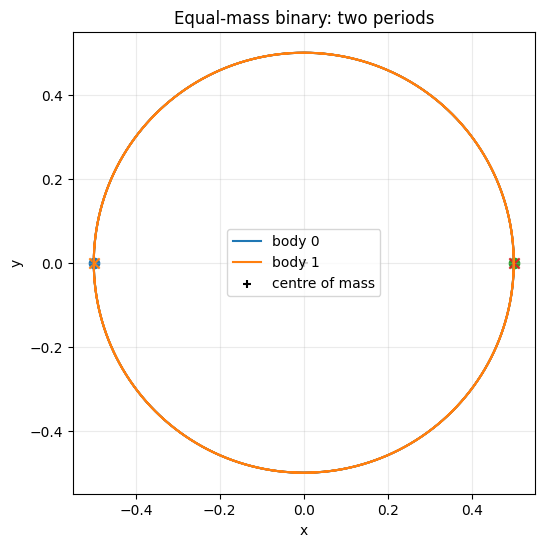

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
for body in range(len(masses)):
    trajectory = np.asarray(position_history[:, body, :])
    ax.plot(trajectory[:, 0], trajectory[:, 1], label=f"body {body}")
    ax.scatter(*trajectory[0], marker="o", s=55)
    ax.scatter(*trajectory[-1], marker="x", s=55)
ax.scatter(0.0, 0.0, color="black", marker="+", label="centre of mass")
ax.set(xlabel="x", ylabel="y", title="Equal-mass binary: two periods")
ax.set_aspect("equal")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

The start and end markers should nearly coincide. That is encouraging but incomplete: a trajectory may close while still violating important invariants between those points.

## 5. Conserved quantities

With no external force, total linear momentum and centre-of-mass velocity are constant. For the softened force used here, the consistent total energy is

$$
E=\tfrac{1}{2}\sum_i m_i\lVert\mathbf v_i\rVert^2
-G\sum_{i<j}\frac{m_im_j}{\sqrt{\lVert\mathbf r_j-\mathbf r_i\rVert^2+\varepsilon^2}}.
$$

Using an unsoftened potential to diagnose softened forces would be internally inconsistent.

In [8]:
def total_energy(
    positions, velocities, masses, gravitational_constant=1.0, softening=0.0
):
    kinetic = 0.5 * jnp.sum(masses[:, None] * velocities**2)

    n_bodies = positions.shape[0]
    displacements = positions[None, :, :] - positions[:, None, :]
    squared_distances = jnp.sum(displacements**2, axis=-1)
    safe_squared_distances = (
        squared_distances
        + softening**2
        + jnp.eye(n_bodies, dtype=positions.dtype)
    )
    pair_masses = masses[:, None] * masses[None, :]
    upper_triangle = jnp.triu(
        jnp.ones((n_bodies, n_bodies), dtype=bool), k=1
    )
    pair_potential = pair_masses / jnp.sqrt(safe_squared_distances)
    potential = -gravitational_constant * jnp.sum(
        jnp.where(upper_triangle, pair_potential, 0.0)
    )
    return kinetic + potential


def total_momentum(velocities, masses):
    return jnp.sum(masses[:, None] * velocities, axis=0)


def centre_of_mass(positions, masses):
    return jnp.sum(masses[:, None] * positions, axis=0) / jnp.sum(masses)

maximum relative energy error: 3.896e-10
maximum momentum error:        0.000e+00
maximum centre-of-mass error:  0.000e+00


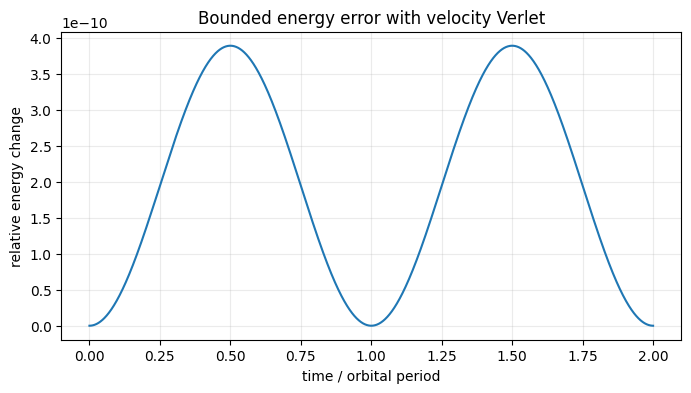

In [9]:
def diagnostics_at_state(positions, velocities):
    energy = total_energy(
        positions, velocities, masses, gravitational_constant, softening
    )
    momentum = total_momentum(velocities, masses)
    com = centre_of_mass(positions, masses)
    return energy, momentum, com


energies, momenta, centres_of_mass = jax.vmap(diagnostics_at_state)(
    position_history, velocity_history
)
relative_energy_change = (energies - energies[0]) / jnp.abs(energies[0])
maximum_energy_error = float(jnp.max(jnp.abs(relative_energy_change)))
maximum_momentum_error = float(
    jnp.max(jnp.linalg.norm(momenta - momenta[0], axis=1))
)
maximum_com_error = float(
    jnp.max(jnp.linalg.norm(centres_of_mass - centres_of_mass[0], axis=1))
)

print(f"maximum relative energy error: {maximum_energy_error:.3e}")
print(f"maximum momentum error:        {maximum_momentum_error:.3e}")
print(f"maximum centre-of-mass error:  {maximum_com_error:.3e}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(times / orbital_period, np.asarray(relative_energy_change))
ax.set(
    xlabel="time / orbital period",
    ylabel="relative energy change",
    title="Bounded energy error with velocity Verlet",
)
ax.grid(alpha=0.25)
plt.show()

A symplectic method generally does not conserve the exact energy at every step. Instead, its energy error typically remains bounded and oscillatory over long integrations. That is qualitatively different from the secular drift often produced by explicit Euler.

## 6. Verify time-step convergence

Velocity Verlet is second order, so the orbit-closing error after one fixed period should decrease approximately as $O(\Delta t^2)$. This experiment tests the full force-plus-integrator implementation.

In [10]:
def closing_error_for_steps(steps):
    dt_test = orbital_period / steps
    final_positions_test, _ = simulate_final_jit(
        initial_positions,
        initial_velocities,
        masses,
        gravitational_constant,
        softening,
        dt_test,
        steps,
    )
    error = jnp.linalg.norm(
        final_positions_test - initial_positions
    ) / separation
    return dt_test, float(error)


step_counts = np.array([125, 250, 500, 1_000])
refinement_results = [closing_error_for_steps(int(n)) for n in step_counts]
time_steps = np.array([item[0] for item in refinement_results])
closing_errors = np.array([item[1] for item in refinement_results])
observed_order = np.polyfit(np.log(time_steps), np.log(closing_errors), 1)[0]

for steps, error in zip(step_counts, closing_errors):
    print(f"{steps:4d} steps per period: closing error = {error:.3e}")
print(f"observed convergence order: {observed_order:.2f}")

 125 steps per period: closing error = 3.738e-03
 250 steps per period: closing error = 9.352e-04
 500 steps per period: closing error = 2.338e-04
1000 steps per period: closing error = 5.847e-05
observed convergence order: 2.00


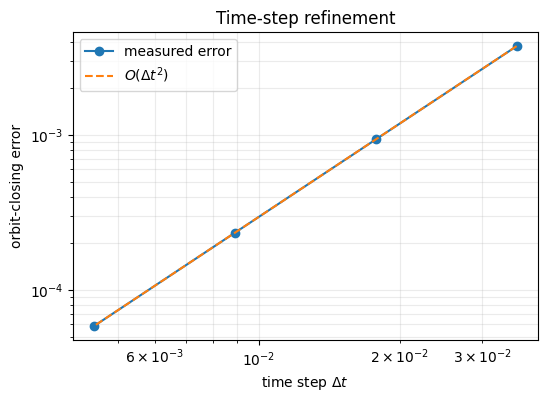

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(time_steps, closing_errors, "o-", label="measured error")
reference = closing_errors[-1] * (time_steps / time_steps[-1]) ** 2
ax.loglog(time_steps, reference, "--", label=r"$O(\Delta t^2)$")
ax.set(xlabel=r"time step $\Delta t$", ylabel="orbit-closing error", title="Time-step refinement")
ax.legend()
ax.grid(which="both", alpha=0.25)
plt.show()

## 7. Use the same solver for three bodies

Three equal masses placed at the vertices of an equilateral triangle can rotate as a rigid configuration. If the side length is $d$ and each mass is $m$, the distance from a vertex to the centre is $d/\sqrt{3}$ and force balance gives

$$\omega=\sqrt{\frac{3Gm}{d^3}}.$$

This is a useful three-body test because its structure is known. Arbitrary three-body initial conditions may be chaotic, making a visually plausible trajectory a poor first validation target.

three-body closing error: 3.675e-05
three-body energy error:  7.696e-11


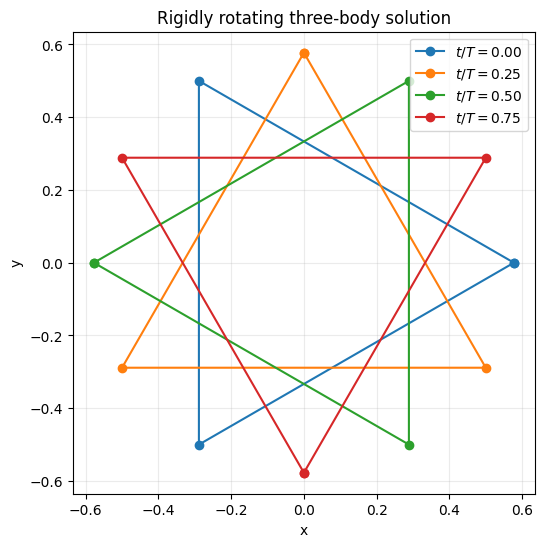

In [12]:
triangle_masses = jnp.ones(3)
triangle_side = 1.0
triangle_radius = triangle_side / np.sqrt(3.0)
triangle_omega = np.sqrt(
    3.0 * gravitational_constant * float(triangle_masses[0]) / triangle_side**3
)
triangle_period = 2.0 * np.pi / triangle_omega
triangle_steps = 1_500
triangle_dt = triangle_period / triangle_steps
triangle_angles = 2.0 * jnp.pi * jnp.arange(3) / 3.0
triangle_initial_positions = triangle_radius * jnp.stack(
    (jnp.cos(triangle_angles), jnp.sin(triangle_angles)), axis=1
)
triangle_initial_velocities = triangle_omega * jnp.stack(
    (-triangle_initial_positions[:, 1], triangle_initial_positions[:, 0]),
    axis=1,
)

triangle_positions, triangle_velocities = simulate_history_jit(
    triangle_initial_positions,
    triangle_initial_velocities,
    triangle_masses,
    gravitational_constant,
    0.0,
    triangle_dt,
    triangle_steps,
)
triangle_closing_error = float(
    jnp.linalg.norm(triangle_positions[-1] - triangle_initial_positions)
    / triangle_side
)

def triangle_energy_at_state(positions, velocities):
    return total_energy(
        positions, velocities, triangle_masses, gravitational_constant, 0.0
    )


triangle_energies = jax.vmap(triangle_energy_at_state)(
    triangle_positions, triangle_velocities
)
triangle_energy_error = float(
    jnp.max(
        jnp.abs((triangle_energies - triangle_energies[0]) / triangle_energies[0])
    )
)
print(f"three-body closing error: {triangle_closing_error:.3e}")
print(f"three-body energy error:  {triangle_energy_error:.3e}")

fig, ax = plt.subplots(figsize=(6, 6))
snapshot_indices = [
    0, triangle_steps // 4, triangle_steps // 2, 3 * triangle_steps // 4
]
for index in snapshot_indices:
    snapshot = np.asarray(triangle_positions[index])
    closed_triangle = np.vstack((snapshot, snapshot[0]))
    ax.plot(
        closed_triangle[:, 0],
        closed_triangle[:, 1],
        marker="o",
        label=fr"$t/T={index / triangle_steps:.2f}$",
    )
ax.set(xlabel="x", ylabel="y", title="Rigidly rotating three-body solution")
ax.set_aspect("equal")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

The array shapes changed from two to three bodies, so JAX compiled a new executable. The force and integrator functions did not change. That is the useful form of generality here: shared numerical logic with shape-specific compiled programs.

## 8. Vectorize an ensemble of initial conditions

Parameter studies often repeat the same simulation for several initial conditions. `jax.vmap` adds a batch dimension without placing that dimension inside the force function. Here we vary the initial orbital speed while sharing masses, force parameters, time step, and step count.

Vectorization exposes more parallel work but retains every batched trajectory below. Its memory use scales with the batch size as well as the number of times and bodies.

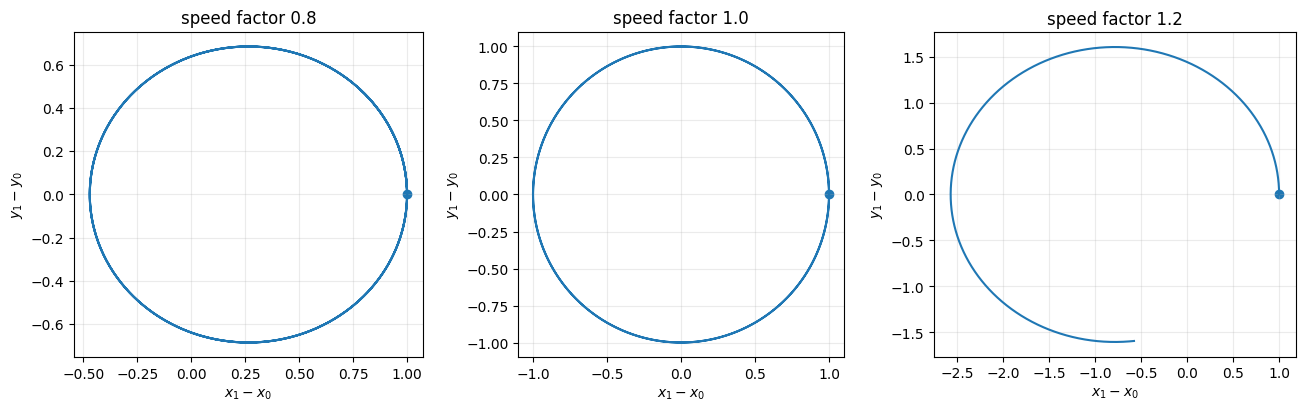

In [13]:
speed_factors = jnp.array([0.8, 1.0, 1.2])
velocity_ensemble = speed_factors[:, None, None] * initial_velocities[None, :, :]

def simulate_one_velocity(velocities):
    return simulate_history(
        initial_positions,
        velocities,
        masses,
        gravitational_constant,
        softening,
        dt,
        n_steps,
    )


simulate_ensemble = jax.jit(jax.vmap(simulate_one_velocity))
ensemble_positions, _ = simulate_ensemble(velocity_ensemble)
ensemble_positions.block_until_ready()

fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
for index, (ax, factor) in enumerate(zip(axes, np.asarray(speed_factors))):
    relative_position = np.asarray(
        ensemble_positions[index, :, 1, :]
        - ensemble_positions[index, :, 0, :]
    )
    ax.plot(relative_position[:, 0], relative_position[:, 1])
    ax.scatter(*relative_position[0], marker="o")
    ax.set(title=f"speed factor {factor:.1f}", xlabel=r"$x_1-x_0$", ylabel=r"$y_1-y_0$")
    ax.set_aspect("equal")
    ax.grid(alpha=0.25)
plt.show()

The circular speed is a special initial condition. Lower or higher bound speeds produce eccentric relative orbits. A sufficiently large speed would make the total energy non-negative and the bodies unbound; plotting alone is not the right criterion for that transition.

## 9. Differentiate a short-horizon observable

We differentiate the vertical position of body 0 after one quarter of the reference period with respect to a scale factor on the initial velocities. The time step and integer step count remain fixed. Differentiating through a rule that changes the number of steps would introduce a discrete, non-smooth choice.

A centred finite difference provides an independent local check. For long chaotic trajectories, an accurately computed tangent derivative can still grow exponentially and become useless for prediction. Automatic differentiation does not remove sensitivity to initial conditions.

In [14]:
sensitivity_steps = steps_per_period // 4

def body_zero_y_at_quarter_period(speed_factor):
    positions, _ = simulate_final(
        initial_positions,
        speed_factor * initial_velocities,
        masses,
        gravitational_constant,
        softening,
        dt,
        sensitivity_steps,
    )
    return positions[0, 1]


observable_and_gradient = jax.jit(
    jax.value_and_grad(body_zero_y_at_quarter_period)
)
observable, autodiff_gradient = observable_and_gradient(1.0)
finite_difference_step = 1.0e-4
finite_difference_gradient = (
    body_zero_y_at_quarter_period(1.0 + finite_difference_step)
    - body_zero_y_at_quarter_period(1.0 - finite_difference_step)
) / (2.0 * finite_difference_step)
gradient_difference = abs(
    float(autodiff_gradient - finite_difference_gradient)
)

print(f"body 0 y coordinate:       {float(observable): .6f}")
print(f"automatic derivative:      {float(autodiff_gradient): .6f}")
print(f"finite-difference estimate: {float(finite_difference_gradient): .6f}")
print(f"absolute difference:        {gradient_difference:.3e}")

body 0 y coordinate:       -0.500005
automatic derivative:      -0.999991
finite-difference estimate: -0.999991
absolute difference:        6.767e-09


## 10. Exercises

The core tutorial ends here. The exercises test method choice and physical invariance rather than asking you to reproduce code mechanically.

### Exercise 1 — compare explicit Euler with velocity Verlet (15 minutes)

Predict how explicit Euler will change the orbital energy over two periods when it uses the same small time step. Then implement or inspect the reference solution, compare energy histories, and decide whether the error is bounded or secular.

**Success criterion:** explain why a smaller local truncation error is not the only reason to prefer the symplectic method for long-lived conservative dynamics.

<details>
<summary><strong>Reasoning</strong></summary>

Explicit Euler is first order and not symplectic. For this orbit it systematically increases the numerical energy, so the bodies spiral apart. Reducing the step delays the failure but does not give the bounded, oscillatory energy error characteristic of velocity Verlet.
</details>

Verlet maximum energy error: 3.896e-10
Euler maximum energy error:  1.214e-01


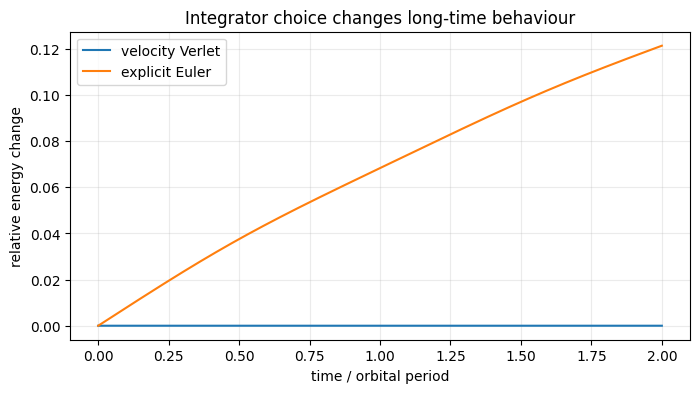

In [15]:
def explicit_euler_step(state, masses, gravitational_constant, softening, dt):
    positions, velocities = state
    current_accelerations = accelerations(
        positions, masses, gravitational_constant, softening
    )
    return positions + dt * velocities, velocities + dt * current_accelerations


def simulate_euler_history(
    positions, velocities, masses, gravitational_constant, softening, dt, n_steps
):
    def body(state, _):
        new_state = explicit_euler_step(
            state, masses, gravitational_constant, softening, dt
        )
        return new_state, new_state

    _, (later_positions, later_velocities) = jax.lax.scan(
        body, (positions, velocities), xs=None, length=n_steps
    )
    return (
        jnp.concatenate((positions[None, :, :], later_positions), axis=0),
        jnp.concatenate((velocities[None, :, :], later_velocities), axis=0),
    )


simulate_euler_jit = jax.jit(
    simulate_euler_history, static_argnames=("n_steps",)
)
euler_positions, euler_velocities = simulate_euler_jit(
    initial_positions,
    initial_velocities,
    masses,
    gravitational_constant,
    softening,
    dt,
    n_steps,
)
def energy_at_state(positions, velocities):
    return total_energy(
        positions, velocities, masses, gravitational_constant, softening
    )


euler_energies = jax.vmap(energy_at_state)(
    euler_positions, euler_velocities
)
euler_relative_energy_change = (
    euler_energies - euler_energies[0]
) / jnp.abs(euler_energies[0])
euler_energy_drift = float(
    jnp.max(jnp.abs(euler_relative_energy_change))
)

print(f"Verlet maximum energy error: {maximum_energy_error:.3e}")
print(f"Euler maximum energy error:  {euler_energy_drift:.3e}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(times / orbital_period, np.asarray(relative_energy_change), label="velocity Verlet")
ax.plot(times / orbital_period, np.asarray(euler_relative_energy_change), label="explicit Euler")
ax.set(xlabel="time / orbital period", ylabel="relative energy change", title="Integrator choice changes long-time behaviour")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

### Exercise 2 — test Galilean invariance (10–15 minutes)

Add the same constant velocity $\mathbf V$ to every body. Predict what happens to:

1. the relative orbit $\mathbf r_1-\mathbf r_0$;
2. the centre of mass; and
3. the total momentum.

Run the solution and interpret the two reported errors.

**Success criterion:** distinguish unchanged internal dynamics from translated centre-of-mass motion.

<details>
<summary><strong>Reasoning</strong></summary>

Gravity depends only on relative positions, so a common velocity boost leaves the relative orbit unchanged. The centre of mass moves as $\mathbf R_{cm}(t)=\mathbf R_{cm}(0)+\mathbf Vt$, and total momentum increases by $M\mathbf V$. This is a physical symmetry and a useful implementation test.
</details>

In [16]:
boost = jnp.array([0.3, -0.2])
boosted_positions, boosted_velocities = simulate_history_jit(
    initial_positions,
    initial_velocities + boost,
    masses,
    gravitational_constant,
    softening,
    dt,
    n_steps,
)
relative_orbit = position_history[:, 1, :] - position_history[:, 0, :]
boosted_relative_orbit = boosted_positions[:, 1, :] - boosted_positions[:, 0, :]
relative_orbit_error = float(
    jnp.max(jnp.linalg.norm(boosted_relative_orbit - relative_orbit, axis=1))
)
def centre_of_mass_at_state(positions):
    return centre_of_mass(positions, masses)


boosted_com = jax.vmap(centre_of_mass_at_state)(boosted_positions)
expected_com = centres_of_mass[0] + jnp.asarray(times)[:, None] * boost
com_translation_error = float(
    jnp.max(jnp.linalg.norm(boosted_com - expected_com, axis=1))
)

print(f"maximum relative-orbit difference: {relative_orbit_error:.3e}")
print(f"maximum COM translation error:     {com_translation_error:.3e}")

maximum relative-orbit difference: 5.290e-14
maximum COM translation error:     5.687e-15


## 11. Limits and production directions

### Advantages of this JAX formulation

- The pair-force, integrator, diagnostics, batching, and differentiation compose from pure array functions.
- The entire time loop can be compiled for CPU or accelerator execution.
- `vmap` expresses independent parameter studies without manually managing a batch axis.
- Conservation and refinement tests remain backend-independent.

### Important limitations

- Direct broadcasting costs $O(N^2)$ work and memory. For large $N$, investigate blocked interactions, tree codes, fast multipole methods, or particle-mesh methods.
- A single global time step is inefficient and possibly inaccurate during close encounters. Adaptive or individual time steps complicate batching and compilation.
- Softening avoids a singularity by modifying short-range physics; its value requires scientific justification and convergence study.
- Storing complete trajectories can dominate memory. Save selected diagnostics or checkpoints instead.
- Long-time N-body dynamics can be chaotic. Trajectory-wise errors and gradients may grow rapidly even when conserved quantities look good.
- This notebook uses dimensionless values and omits units, collisions, external potentials, relativistic corrections, and domain-specific validation.

A GPU does not rescue an $O(N^2)$ algorithm from poor asymptotic scaling. Choose the physical and numerical method first, then optimize and benchmark the representative workload.

## 12. Reproducibility checks

These assertions cover the tutorial's explicit claims. They do not establish that this solver is appropriate for a large or scientifically specific N-body problem.

In [17]:
assert closing_error < 1.0e-3
assert 1.8 < observed_order < 2.2
assert maximum_energy_error < 1.0e-8
assert maximum_momentum_error < 1.0e-12
assert maximum_com_error < 1.0e-12
assert triangle_closing_error < 1.0e-3
assert triangle_energy_error < 1.0e-8
assert gradient_difference < 1.0e-4
assert euler_energy_drift > 100.0 * maximum_energy_error
assert relative_orbit_error < 1.0e-10
assert com_translation_error < 1.0e-10
print("All N-body tutorial checks passed.")

All N-body tutorial checks passed.


## References

- [JAX: Arrays and data structures](https://docs.jax.dev/en/latest/pytrees.html)
- [JAX: `lax.scan`](https://docs.jax.dev/en/latest/_autosummary/jax.lax.scan.html)
- [JAX: Automatic vectorization](https://docs.jax.dev/en/latest/automatic-vectorization.html)
- [JAX: The Autodiff Cookbook](https://docs.jax.dev/en/latest/notebooks/autodiff_cookbook.html)
- [JAX: Benchmarking](https://docs.jax.dev/en/latest/benchmarking.html)